<a href="https://colab.research.google.com/github/Kigunda-lilian/Data_science/blob/main/lec11_notebook_answer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 11 Unsupervised Learning

### 1.2 Importing Libraries Used in This Chapter
In this chapter, we will use the same libraries as in previous chapters, including Scikit-learn for machine learning. The content assumes that these libraries have been imported as shown below.

In [ ]:
# Data processing and analysis libraries
import numpy as np
import numpy.random as random
import scipy as sp
from pandas import Series, DataFrame
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline

# Machine learning libraries
import sklearn

# Display up to 3 decimal places
%precision 3

'%.3f'

#### Download and Load the Analysis Data
The data used for this analysis is the learning data provided at the following URL, specifically the bank-full.csv file included in the package.

http://archive.ics.uci.edu/static/public/222/bank+marketing.zip










In [ ]:
# Import libraries for downloading data from the web and handling zip files
import requests, zipfile
import io
import warnings
warnings.simplefilter('ignore')

# Specify the URL wehre the data is located
!wget "http://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
# Unzip the bank+marketing.zip file
!unzip "./bank+marketing.zip"
# Unzip the bank.zip file
!unzip "./bank.zip"

--2026-06-17 07:42:57--  http://archive.ics.uci.edu/static/public/222/bank+marketing.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank+marketing.zip’

bank+marketing.zip      [    <=>             ] 999.85K   950KB/s    in 1.1s    

2026-06-17 07:42:59 (950 KB/s) - ‘bank+marketing.zip’ saved [1023843]

Archive:  ./bank+marketing.zip
 extracting: bank.zip                
 extracting: bank-additional.zip     
Archive:  ./bank.zip
  inflating: bank-full.csv           
  inflating: bank-names.txt          
  inflating: bank.csv                


Next, we load the target data, `bank-full.csv`, using Pandas.　The delimiter is set using the `sep` parameter. The first 5 rows are displayed using the `head` method, as shown below.








In [ ]:
# Load the target data
bank = pd.read_csv('bank-full.csv', sep=';')

# Display the first 5 rows
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


####  <Practice Question 1>
Use the data generated with `make_blobs()` function as implemented below and perform clustering. How many clusters will you divide it into? Once divided, plot the result by coloring the individual cluster in different colors.

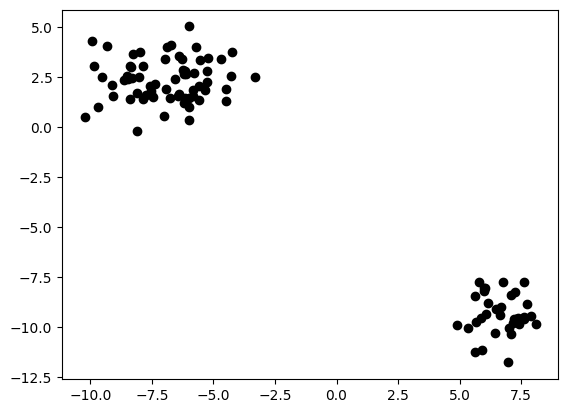

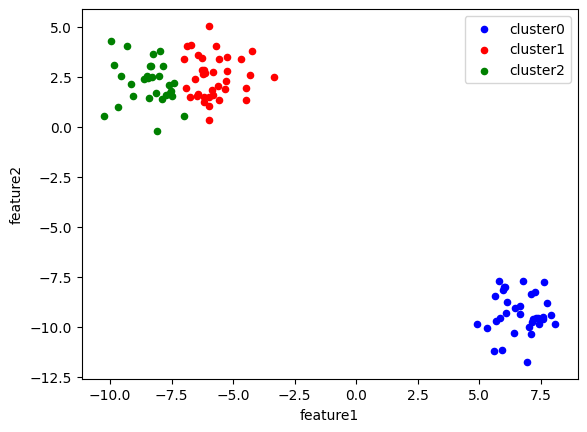

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create dataset
X, y = make_blobs(random_state=52)
plt.scatter(X[:,0], X[:,1], color='black')

## WRITE ME
# Initializing the k-means class
kmeans = KMeans(init='random', n_clusters=3)

# Calculating the cluster centroids
kmeans.fit(X)

# Predicting the cluster numbers
y_pred = kmeans.predict(X)

# Concatenating data horizontally using concat (specifying axis=1)
merge_data = pd.concat([pd.DataFrame(X[:,0]), pd.DataFrame(X[:,1]), pd.DataFrame(y_pred)], axis=1)

# Specifying column names for the data
merge_data.columns = ['feature1','feature2','cluster']

# Visualizing the clustering results
ax = None
colors = ['blue', 'red', 'green']
for i, data in merge_data.groupby('cluster'):
    ax = data.plot.scatter(x='feature1', y='feature2', color=colors[i],
                                           label=f'cluster{i}', ax=ax)

n_clusters = 2
Cluster counts:
0    66
1    34
Name: count, dtype: int64

n_clusters = 3
Cluster counts:
0    29
1    34
2    37
Name: count, dtype: int64

n_clusters = 4
Cluster counts:
2    20
0    34
3    22
1    24
Name: count, dtype: int64



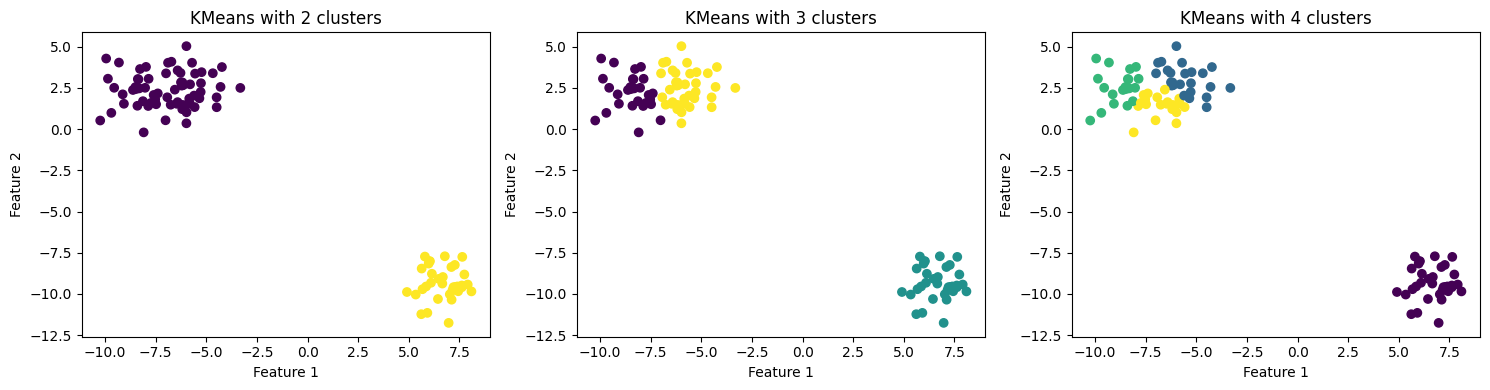

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create dataset
X, y = make_blobs(random_state=52)

# Compare different numbers of clusters
cluster_numbers = [2, 3, 4]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, cluster_numbers):
    kmeans = KMeans(n_clusters=k, random_state=52, n_init=10)
    labels = kmeans.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels)
    ax.set_title(f"KMeans with {k} clusters")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    print(f"n_clusters = {k}")
    print("Cluster counts:")
    print(pd.Series(labels).value_counts(sort=False))
    print()

plt.tight_layout()
plt.show()

**Answer: 2 clusters**

The reason is that the scatter plot shows two clearly separated groups of points.  
One group is in the upper-left area, and the other group is in the lower-right area.

When `n_clusters=2`, KMeans separates these two groups in a simple and natural way.  
When `n_clusters=3` or `n_clusters=4`, the upper-left group is divided into smaller parts, but those extra divisions are not necessary.

Therefore, the appropriate number of clusters is **2**.

####  <Practice Question 2>
What would the result be if you performed k-means clustering with 4 clusters on the previously handled data, `bank_sub_std`? Similar to <Practice Question 6-1>, after obtaining the cluster numbers, analyze each cluster and interpret their characteristics. Also, what would happen if you set the number of clusters to 8? Additionally, what if you select variables other than `age`, `balance`, `campaign`, and `previous`?

cluster_number
7     8067
6    12055
5    17012
2     2439
4     3716
3      217
1      701
0     1004
Name: count, dtype: int64


Text(0, 0.5, 'count')

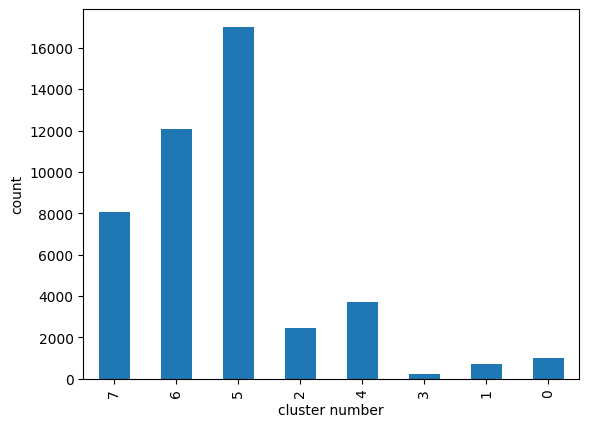

In [ ]:
# Initializing k-means class
kmeans = KMeans(init='random', n_clusters=8, random_state=0)

# Calculating the cluster centroids
kmeans.fit(bank_sub_std)

# Converting the cluster numbers to a pandas Series object
labels = pd.Series(kmeans.labels_, name='cluster_number')

# Displaying the cluster numbers and counts
print(labels.value_counts(sort=False))

# Plotting the graph
ax = labels.value_counts(sort=False).plot(kind='bar')
ax.set_xlabel('cluster number')
ax.set_ylabel('count')

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Use these variables for clustering
bank_sub = bank[['age', 'balance', 'campaign', 'previous']]

# Standardize the data
sc = StandardScaler()
bank_sub_std = sc.fit_transform(bank_sub)

In [ ]:
# KMeans with 4 clusters
kmeans4 = KMeans(
    init='random',
    n_clusters=4,
    random_state=0,
    n_init=10
)

cluster4 = pd.Series(
    kmeans4.fit_predict(bank_sub_std),
    name='cluster_number'
)

bank_cluster4 = pd.concat(
    [bank_sub.reset_index(drop=True), cluster4],
    axis=1
)

print('n_clusters = 4')
print('Cluster counts:')
print(bank_cluster4['cluster_number'].value_counts(sort=False))

print('\nCluster means:')
bank_cluster4.groupby('cluster_number').mean().round(2)

n_clusters = 4
Cluster counts:
cluster_number
2    15861
3    26310
0     1332
1     1708
Name: count, dtype: int64

Cluster means:


,age,balance,campaign,previous
cluster_number,,,,
0,43.38,13942.76,2.44,0.63
1,40.19,921.47,14.58,0.12
2,52.34,1165.25,2.40,0.51
3,33.98,872.75,2.23,0.65


In [ ]:
# KMeans with 8 clusters
kmeans8 = KMeans(
    init='random',
    n_clusters=8,
    random_state=0,
    n_init=10
)

cluster8 = pd.Series(
    kmeans8.fit_predict(bank_sub_std),
    name='cluster_number'
)

bank_cluster8 = pd.concat(
    [bank_sub.reset_index(drop=True), cluster8],
    axis=1
)

print('n_clusters = 8')
print('Cluster counts:')
print(bank_cluster8['cluster_number'].value_counts(sort=False))

print('\nCluster means:')
bank_cluster8.groupby('cluster_number').mean().round(2)

n_clusters = 8
Cluster counts:
cluster_number
7     8067
6    12055
5    17012
2     2439
4     3716
3      217
1      701
0     1004
Name: count, dtype: int64

Cluster means:


,age,balance,campaign,previous
cluster_number,,,,
0,40.54,1317.61,2.65,10.25
1,39.94,970.33,20.26,0.00
2,42.09,8289.13,2.25,0.48
3,46.41,29022.93,2.72,0.46
4,39.97,804.62,7.53,0.18
5,31.50,714.02,1.93,0.40
6,43.48,737.17,1.94,0.34
7,57.11,1121.60,2.21,0.40


In [ ]:
# Try different variables
bank_sub_other = bank[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']]

# Standardize the data
sc = StandardScaler()
bank_sub_other_std = sc.fit_transform(bank_sub_other)

# KMeans with 4 clusters
kmeans4_other = KMeans(
    init='random',
    n_clusters=4,
    random_state=0,
    n_init=10
)

cluster4_other = pd.Series(
    kmeans4_other.fit_predict(bank_sub_other_std),
    name='cluster_number'
)

bank_cluster4_other = pd.concat(
    [bank_sub_other.reset_index(drop=True), cluster4_other],
    axis=1
)

print('n_clusters = 4 with different variables')
print('Cluster counts:')
print(bank_cluster4_other['cluster_number'].value_counts(sort=False))

print('\nCluster means:')
bank_cluster4_other.groupby('cluster_number').mean().round(2)

n_clusters = 4 with different variables
Cluster counts:
cluster_number
3    14396
0    22851
2     1640
1     6324
Name: count, dtype: int64

Cluster means:


,age,balance,duration,campaign,pdays,previous
cluster_number,,,,,,
0,34.14,919.36,273.21,2.29,2.51,0.07
1,39.37,1348.48,257.58,2.12,261.55,3.55
2,40.25,1076.60,152.70,14.82,0.14,0.03
3,52.49,2103.92,246.55,2.43,7.35,0.15


**Answer**

When `n_clusters=4`, the data is divided into four broad customer groups.

The characteristics of each cluster can be understood by comparing the average values of `age`, `balance`, `campaign`, and `previous`.

For example, a cluster with a higher average `age` can be interpreted as an older-customer group.  
A cluster with a higher average `balance` can be interpreted as a higher-balance customer group.  
A cluster with a higher average `campaign` can be interpreted as a group that was contacted many times during the current campaign.  
A cluster with a higher average `previous` can be interpreted as a group that had more contact in previous campaigns.

When `n_clusters=8`, the data is divided into smaller groups.  
This gives more detailed clusters, but the result is harder to interpret than the 4-cluster result.

When different variables are used, the clustering result changes because KMeans forms clusters based on the variables included in the model.  
For example, if `duration` and `pdays` are added, the clusters are influenced more by contact duration and previous contact history.

####  <Practice Question 3>
Use the `load_iris` function from the `sklearn.datasets` module to load the Iris dataset, and perform principal component analysis (PCA) on `iris.data`. The number of principal components to extract should be set to 2. Additionally, analyze the relationship between the data reduced to the second principal component and the target variable (`iris.target`) using visualizations, such as graphs.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
sc = StandardScaler()
sc.fit(iris.data)
X_std = sc.transform(iris.data)

# Principal component analysis
pca = PCA(n_components=2)
pca.fit(X_std)
X_pca_array = pca.transform(X_std)

# Display basic results
print('X_pca shape: {}'.format(X_pca_array.shape))
print('Explained variance ratio: {}'.format(pca.explained_variance_ratio_))
print('Total explained variance ratio: {:.3f}'.format(pca.explained_variance_ratio_.sum()))

# Create a DataFrame with principal components and target
X_pca = pd.DataFrame(X_pca_array, columns=['pc1', 'pc2'])
X_pca = pd.concat([X_pca, pd.DataFrame(iris.target, columns=['target'])], axis=1)

# Show the average values of pc1 and pc2 by target
X_pca.groupby('target')[['pc1', 'pc2']].mean().round(3)

X_pca shape: (150, 2)
Explained variance ratio: [0.73  0.229]
Total explained variance ratio: 0.958


,pc1,pc2
target,,
0,-2.225,0.289
1,0.496,-0.550
2,1.728,0.261


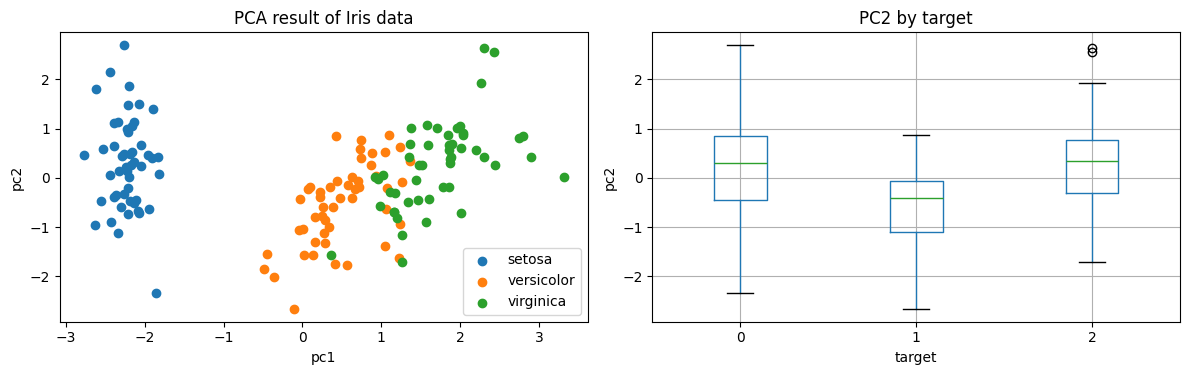

In [ ]:
# Visualize PCA results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter plot of pc1 and pc2
for target in [0, 1, 2]:
    data = X_pca[X_pca['target'] == target]
    axes[0].scatter(data['pc1'], data['pc2'], label=iris.target_names[target])

axes[0].set_xlabel('pc1')
axes[0].set_ylabel('pc2')
axes[0].set_title('PCA result of Iris data')
axes[0].legend()

# Boxplot of pc2 by target
X_pca.boxplot(column='pc2', by='target', ax=axes[1])
axes[1].set_xlabel('target')
axes[1].set_ylabel('pc2')
axes[1].set_title('PC2 by target')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 4 Market Basket Analysis and Association Rules
Keywords: Association Rules, Support, Confidence, Lift

### 4.2 Loading Sample Data for Market Basket Analysis

In this section, we will use the purchase history data, which is a type of transaction data, to demonstrate Market Basket Analysis.

The purchase history data is often referred to as transaction data. We will load this data using the variable name `trans`. Note that this dataset is relatively large, with more than 500,000 records, so it may take some time to load.

In [ ]:
# Download data from the UCI website
!wget "http://archive.ics.uci.edu/static/public/352/online+retail.zip"
# Unzip the downloaded ZIP file
!unzip "./online+retail.zip"

--2026-06-16 06:49:16--  http://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘online+retail.zip’

online+retail.zip       [   <=>              ]  22.62M  48.0MB/s    in 0.5s    

2026-06-16 06:49:17 (48.0 MB/s) - ‘online+retail.zip’ saved [23715478]

Archive:  ./online+retail.zip
 extracting: Online Retail.xlsx      


The following execution example shows the first 5 records using `head` method.

Note: In the purchase history data, `InvoiceNo` represents the invoice number. Transactions with the same `InvoiceNo` correspond to items listed in the same invoice. Therefore, items with the same `InvoiceNo` were purchased together in the same transaction.

Additionally, depending on your environment, you may need to install the xlrd module by running `pip3 install xlrd`.

In [ ]:
# Reading the file and displaying it
file_url = './Online Retail.xlsx'
trans = pd.ExcelFile(file_url)
trans = trans.parse('Online Retail')
trans.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


#### Data Organization and Verification

In this transaction history data, the first character of the `InvoiceNo` indicates the status of the transaction. "5" represents regular data, "C" represents cancellations, and "A" represents unknown data. First, we'll add the first character of `InvoiceNo` as a separate variable called `cancel_flg`. After adding it, we'll count and aggregate the records by each value of `cancel_flg`. In practice, aggregation conditions greatly depend on the analysis purpose and data management status, so it's important to verify these thoroughly.

In [ ]:
# Adding the first character of InvoiceNo as cancel_flg
trans['cancel_flg'] = trans.InvoiceNo.map(lambda x:str(x)[0])

# Group by cancel_flg and aggregate the data
trans.groupby('cancel_flg').size()

,0
cancel_flg,
5,532618
A,3
C,9288


We will only work with the data where the `InvoiceNo` starts with "5" (normal data) and where the `CustomerID` is not missing. To filter these data, use the following code. If you are unsure about this process, try reviewing the Pandas chapter or searching for "Pandas filter" on a search engine.

In [ ]:
trans = trans[(trans.cancel_flg == '5') & (trans.CustomerID.notnull())]

####  <Practice Question 4>

Using the purchase history data from Section 4 "Market Basket Analysis and Association Rules," calculate the support, confidence, and lift values for other combinations of products of your choice.

In [ ]:
# Change StockCode to string type
trans = trans.astype({'StockCode': 'str'})

# Extract all invoices
trans_all = set(trans.InvoiceNo)

# Choose product combinations
pairs = [
    ('22632', '22633'),
    ('22726', '22727'),
    ('22697', '22699')
]

results = []

for item_a, item_b in pairs:
    # Extract invoices containing item A
    trans_a = set(trans[trans['StockCode'] == item_a].InvoiceNo)

    # Extract invoices containing item B
    trans_b = set(trans[trans['StockCode'] == item_b].InvoiceNo)

    # Extract invoices containing both item A and item B
    trans_ab = trans_a & trans_b

    # Calculate support
    support = len(trans_ab) / len(trans_all)

    # Calculate confidence: item A -> item B
    confidence = len(trans_ab) / len(trans_a)

    # Calculate support of item B
    support_b = len(trans_b) / len(trans_all)

    # Calculate lift
    lift = confidence / support_b

    results.append([
        item_a,
        item_b,
        len(trans_a),
        len(trans_b),
        len(trans_ab),
        support,
        confidence,
        lift
    ])

# Display results
result_df = pd.DataFrame(
    results,
    columns=[
        'item_A',
        'item_B',
        'count_A',
        'count_B',
        'count_AB',
        'support',
        'confidence',
        'lift'
    ]
)

result_df.round(3)

,item_A,item_B,count_A,count_B,count_AB,support,confidence,lift
0,22632,22633,359,441,166,0.009,0.462,19.435
1,22726,22727,789,877,530,0.029,0.672,14.198
2,22697,22699,691,783,541,0.029,0.783,18.534


## 5 Comprehensive Questions

### ■ Comprehensive Question 1 Association Rules

Using the purchase history data from Section 4, which combination of products has the highest support? However, calculate this for products (`StockCode`) that have more than 1,000 records.

(Hint: When extracting product combinations, the `itertools` module is useful. If you're not sure how to use it, try searching for "Python itertools.")

**Acknowledgement**:
The following two datasets were used:

1. http://archive.ics.uci.edu/static/public/222/bank+marketing.zip
2. http://archive.ics.uci.edu/static/public/352/online+retail.zip

Source: Markelle Kelly, Rachel Longjohn, Kolby Nottingham,
The UCI Machine Learning Repository, https://archive.ics.uci.edu

- Citation for Dataset 1:
[Moro et al., 2014] S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing. Decision Support Systems, Elsevier, 62:22-31, June 2014
- Citation for Dataset 2:  
Daqing Chen, Sai Liang Sain, and Kun Guo, Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining, Journal of Database Marketing and Customer Strategy Management, Vol. 19, No. 3, pp. 197â€“208, 2012 (Published online before print: 27 August 2012. doi: 10.1057/dbm.2012.17).

In [ ]:
from itertools import combinations

# Change StockCode to string type
trans = trans.astype({'StockCode': 'str'})

# Extract all baskets
trans_all = set(trans['InvoiceNo'])
total_baskets = len(trans_all)

# Select products that appear more than 1,000 times
stock_counts = trans['StockCode'].value_counts()
target_stock = stock_counts[stock_counts > 1000].index

# Use only selected products
trans_target = trans[trans['StockCode'].isin(target_stock)]

# Remove duplicated StockCode within the same invoice
trans_target = trans_target[['InvoiceNo', 'StockCode']].drop_duplicates()

# Create product combinations for each invoice
pair_counts = {}

for invoice_no, group in trans_target.groupby('InvoiceNo'):
    items = sorted(group['StockCode'].tolist())

    for pair in combinations(items, 2):
        if pair in pair_counts:
            pair_counts[pair] += 1
        else:
            pair_counts[pair] = 1

# Create result table
result = []

for pair, count in pair_counts.items():
    support = count / total_baskets

    result.append([
        pair[0],
        pair[1],
        count,
        support
    ])

result_df = pd.DataFrame(
    result,
    columns=['item_A', 'item_B', 'count_AB', 'support']
)

# Sort by support
result_df = result_df.sort_values('support', ascending=False).reset_index(drop=True)

# Show top 10 combinations
result_df.head(10)

,item_A,item_B,count_AB,support
0,20725,22383,519,0.028000
1,20725,20727,517,0.027892
2,23203,85099B,468,0.025248
3,20725,22382,467,0.025194
4,20727,22383,465,0.025086
5,22382,22383,447,0.024115
6,23203,23209,443,0.023899
7,20725,85099B,425,0.022928
8,20725,23209,419,0.022605
9,20727,22382,418,0.022551


In [ ]:
# Add product descriptions
stock_description = trans[['StockCode', 'Description']].drop_duplicates('StockCode')

result_df = result_df.merge(
    stock_description,
    left_on='item_A',
    right_on='StockCode',
    how='left'
)

result_df = result_df.rename(columns={'Description': 'item_A_description'})
result_df = result_df.drop(columns='StockCode')

result_df = result_df.merge(
    stock_description,
    left_on='item_B',
    right_on='StockCode',
    how='left'
)

result_df = result_df.rename(columns={'Description': 'item_B_description'})
result_df = result_df.drop(columns='StockCode')

result_df.head(10)

,item_A,item_B,count_AB,support,item_A_description,item_B_description
0,20725,22383,519,0.028000,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN
1,20725,20727,517,0.027892,LUNCH BAG RED RETROSPOT,LUNCH BAG BLACK SKULL.
2,23203,85099B,468,0.025248,JUMBO BAG DOILEY PATTERNS,JUMBO BAG RED RETROSPOT
3,20725,22382,467,0.025194,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN
4,20727,22383,465,0.025086,LUNCH BAG BLACK SKULL.,LUNCH BAG SUKI DESIGN
5,22382,22383,447,0.024115,LUNCH BAG SPACEBOY DESIGN,LUNCH BAG SUKI DESIGN
6,23203,23209,443,0.023899,JUMBO BAG DOILEY PATTERNS,LUNCH BAG DOILEY PATTERN
7,20725,85099B,425,0.022928,LUNCH BAG RED RETROSPOT,JUMBO BAG RED RETROSPOT
8,20725,23209,419,0.022605,LUNCH BAG RED RETROSPOT,LUNCH BAG DOILEY PATTERN
9,20727,22382,418,0.022551,LUNCH BAG BLACK SKULL.,LUNCH BAG SPACEBOY DESIGN
